<a href="https://colab.research.google.com/github/bismillah626/spam_project/blob/main/spam_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np

# ***#1 Data cleaning***

In [4]:
df = pd.read_csv('/content/spam.csv',encoding='latin-1').dropna(axis =1,how = 'any')
df.columns = ['labels','message']
df

,labels,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [5]:
df.isnull().sum()

,0
labels,0
message,0


In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['labels'] = le.fit_transform(df['labels'])

In [7]:
df.sample(5)

,labels,message
2264,0,Ok . . now i am in bus. . If i come soon i wil...
2525,0,"Say this slowly.? GOD,I LOVE YOU &amp; I NEED ..."
1513,0,Hows the champ just leaving glasgow!
5159,0,No but the bluray player can
5521,0,You are a big chic. Common. Declare


In [8]:
#checking for duplicate values
df.duplicated().sum()

np.int64(403)

In [9]:
df  = df.drop_duplicates(keep = 'first')

In [10]:
df.shape

(5169, 2)

# ***#2 EDA***

In [11]:
#checks if the data is balanced or not
df['labels'].value_counts()

,count
labels,
0,4516
1,653


Text(0, 0.5, 'count')

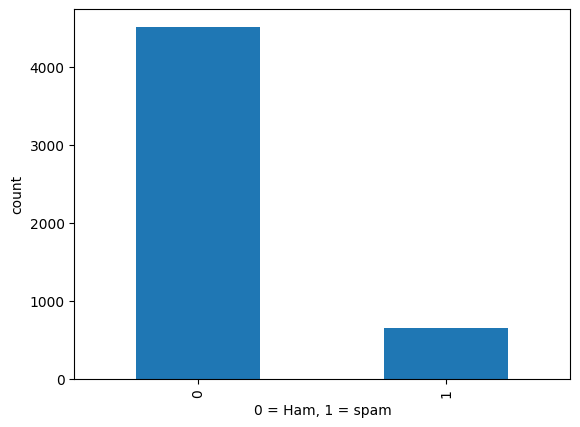

In [12]:
#schematic representation of data in piechart and bargraph format
import matplotlib.pyplot as plt
df['labels'].value_counts().plot(kind = 'bar')
plt.xlabel('0 = Ham, 1 = spam')
plt.ylabel('count')


([<matplotlib.patches.Wedge at 0x79a5975ff7a0>,
 [Text(-1.014499732282844, 0.4251944181172162, 'ham'),
  Text(1.0144998708287172, -0.42519408755122207, 'spam')],
 [Text(-0.5533634903360967, 0.2319242280639361, '87.37'),
  Text(0.553363565906573, -0.231924047755212, '12.63')])

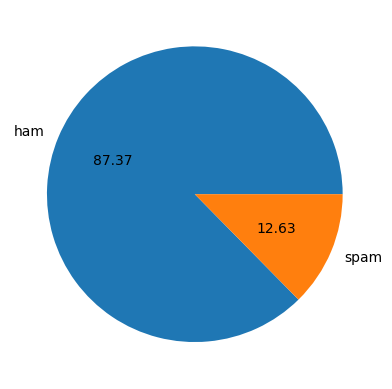

In [13]:
#piechart
plt.pie(df['labels'].value_counts(),labels = ['ham','spam'],autopct = '%0.2f')


In [14]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [21]:
df['characters_count'] = df['message'].apply(len)

/tmp/ipython-input-1212001223.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['characters_count'] = df['message'].apply(len)


In [16]:
df.sample(5)

,labels,message,no. of characters
9,1,Had your mobile 11 months or more? U R entitle...,154
5462,1,Txt: CALL to No: 86888 & claim your reward of ...,147
5481,0,Shall call now dear having food,31
3191,0,Is ur paper today in e morn or aft?,35
235,0,I have printed it oh. So &lt;#&gt; come upst...,50


In [20]:
df['words_count'] = df['message'].apply(lambda x: len(nltk.tokenize.word_tokenize(x)))

/tmp/ipython-input-267352958.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['words_count'] = df['message'].apply(lambda x: len(nltk.tokenize.word_tokenize(x)))


In [22]:
df['sentence count'] = df['message'].apply(lambda x: len(nltk.sent_tokenize(x)))

/tmp/ipython-input-1666743428.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sentence count'] = df['message'].apply(lambda x: len(nltk.sent_tokenize(x)))


In [23]:
df.head()

,labels,message,no. of characters,no.of words,sentence count,words_count,characters_count
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,24,111
1,0,Ok lar... Joking wif u oni...,29,8,2,8,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,37,155
3,0,U dun say so early hor... U c already then say...,49,13,1,13,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,15,61


In [25]:
df = df.drop(columns=['no. of characters','no.of words'])

In [26]:
df.sample(5)

,labels,message,sentence count,words_count,characters_count
3544,0,Thank You meet you monday,1,5,25
1882,0,"Sorry, I can't help you on this.",1,10,32
4336,0,on a Tuesday night r u 4 real,1,8,29
2968,0,Ma head dey swell oh. Thanks for making my day,2,11,46
5147,1,Get your garden ready for summer with a FREE s...,2,28,156


In [27]:
df[['sentence count','words_count','characters_count']].describe()

,sentence count,words_count,characters_count
count,5169.000000,5169.000000,5169.000000
mean,1.965564,18.455794,78.977945
std,1.448541,13.324758,58.236293
min,1.000000,1.000000,2.000000
25%,1.000000,9.000000,36.000000
50%,1.000000,15.000000,60.000000
75%,2.000000,26.000000,117.000000
max,38.000000,220.000000,910.000000


In [30]:
#spam message analysis
df[df['labels']==1][['sentence count', 'words_count', 'characters_count']].describe()

,sentence count,words_count,characters_count
count,653.000000,653.000000,653.000000
mean,2.970904,27.667688,137.891271
std,1.488425,7.008418,30.137753
min,1.000000,2.000000,13.000000
25%,2.000000,25.000000,132.000000
50%,3.000000,29.000000,149.000000
75%,4.000000,32.000000,157.000000
max,9.000000,46.000000,224.000000


In [32]:
#ham  message analysis
df[df['labels']==0][['sentence count', 'words_count', 'characters_count']].describe()


,sentence count,words_count,characters_count
count,4516.000000,4516.000000,4516.000000
mean,1.820195,17.123782,70.459256
std,1.383657,13.493970,56.358207
min,1.000000,1.000000,2.000000
25%,1.000000,8.000000,34.000000
50%,1.000000,13.000000,52.000000
75%,2.000000,22.000000,90.000000
max,38.000000,220.000000,910.000000
